# Faculty Hands-On Activity  
## Build, Compare and Interpret the Same Linear Regression Model

**Suggested time:** 15–20 minutes

### Learning objective
By the end of this activity, you should be able to:

- change the train-test split,
- retrain a Linear Regression model,
- record the intercept and slope,
- calculate MAE, RMSE and R²,
- make new salary predictions,
- interpret the regression slope,
- calculate residuals,
- identify the test observation with the largest absolute residual.

> **Instructions:** Run each cell in order. Complete the cells marked **YOUR TASK**.


## 1. Import the required libraries

Run the following cell first.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset

For this activity, we will use a simple **Years of Experience vs Salary** dataset.

- **YearsExperience** → input feature
- **Salary_Lakh** → target variable

If you already have the dataset used in the earlier session, you may replace the dataframe below with that dataset.


In [5]:
df = pd.read_csv("Faculty_Experience_Salary_Linear_Regression.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30, 3)


,Faculty_ID,Experience_Years,Salary_Lakhs
0,F01,0.5,3.61
1,F02,1.0,3.72
2,F03,1.5,4.53
3,F04,2.0,4.39
4,F05,2.5,5.15


## 3. Explore the dataset


,Faculty_ID,Experience_Years,Salary_Lakhs
0,F01,0.5,3.61
1,F02,1.0,3.72
2,F03,1.5,4.53
3,F04,2.0,4.39
4,F05,2.5,5.15
5,F06,3.0,5.81
6,F07,3.5,5.67
7,F08,4.0,6.53
8,F09,4.5,6.54
9,F10,5.0,7.15


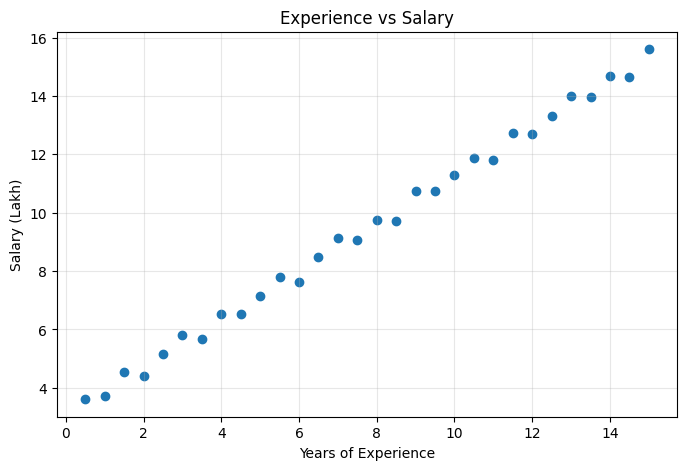

In [8]:
display(df)

plt.figure(figsize=(8, 5))
plt.scatter(df["Experience_Years"], df["Salary_Lakhs"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary (Lakh)")
plt.title("Experience vs Salary")
plt.grid(alpha=0.3)
plt.show()

## 4. Prepare X and y


In [9]:
X = df[["Experience_Years"]]
y = df["Salary_Lakhs"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 1)
y shape: (30,)


# Task 1 — Change the train-test split

Earlier, the model used:

```python
test_size=0.20
```

For this activity, change it to:

```python
test_size=0.25
```

Keep `random_state=42` so that everyone gets the same split.

### YOUR TASK
Complete the code below and run it.


In [12]:
# YOUR TASK: Set test_size to 0.25

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25 ,   # Replace _____ with the required value
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records :", len(X_test))

Training records: 22
Testing records : 8


## Train the Linear Regression model

Run this cell after completing Task 1.


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


# Task 2 — Record the new model

Find and record:

- Intercept
- Slope
- MAE
- RMSE
- R²

### Helpful formulas

- **MAE** = Mean Absolute Error
- **RMSE** = Square root of Mean Squared Error
- **R²** = Coefficient of Determination

Complete the code below.


In [14]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

# YOUR TASK: Fill in the missing parts

intercept = model.intercept_
slope = model.coef_[0]

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MODEL RESULTS")
print("-" * 35)
print(f"Intercept : {intercept:.4f}")
print(f"Slope     : {slope:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"R²        : {r2:.4f}")

MODEL RESULTS
-----------------------------------
Intercept : 3.0493
Slope     : 0.8247
MAE       : 0.1726
RMSE      : 0.2060
R²        : 0.9952


### Record your results

After running the previous cell, write your values below.

| Metric | Your Result |
|---|---|
| Intercept |  3.0493 |
| Slope | 0.8247 |
| MAE | 0.1726 |
| RMSE | 0.2060 |
| R² | 0.9952 |


## Visualize the fitted regression line

Run this cell to compare the observed data with the fitted model.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


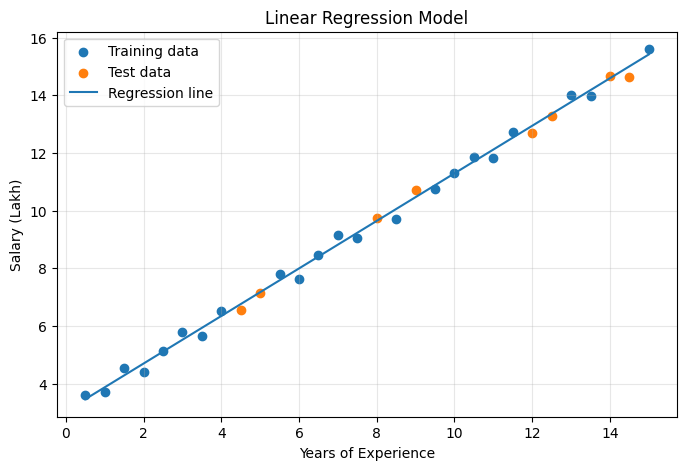

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train["Experience_Years"], y_train, label="Training data")
plt.scatter(X_test["Experience_Years"], y_test, label="Test data")

x_line = np.linspace(df["Experience_Years"].min(), df["Experience_Years"].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, label="Regression line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (Lakh)")
plt.title("Linear Regression Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Task 3 — Make three new predictions

Use the trained model to predict salary for:

- **4.5 years**
- **8 years**
- **12 years**

### YOUR TASK
Complete the list below.


In [16]:
# YOUR TASK: Enter the three experience values

new_experience = pd.DataFrame({
    "Experience_Years": [4.5, 8, 12]
})

predicted_salary = model.predict(new_experience)

prediction_table = new_experience.copy()
prediction_table["PredictedSalary_Lakh"] = predicted_salary

prediction_table

,Experience_Years,PredictedSalary_Lakh
0,4.5,6.760355
1,8.0,9.646701
2,12.0,12.945381


### Write your predictions

| Experience | Predicted Salary (Lakh) |
|---:|---:|
| 4.5 years | 6.760355 |
| 8 years | 9.646701 |
| 12 years | 12.945381|


# Task 4 — Interpret the slope

Complete the sentence using the slope obtained from your model:

> **“According to this model, one additional year of experience is associated with approximately 0.8246700507614216 lakh increase in predicted salary.”**

### Think about it
The slope tells us how much the **predicted salary changes** when experience increases by **one year**.


In [17]:
# OPTIONAL: Print the slope again to help with your interpretation
print("Slope =", model.coef_[0])

Slope = 0.8246700507614216


# Task 5 — Find the largest test residual

A **residual** is:

**Residual = Actual Salary − Predicted Salary**

Create a table containing:

- Experience
- Actual salary
- Predicted salary
- Residual
- Absolute residual

Then identify the record with the **largest absolute residual**.

### YOUR TASK
Complete the missing code.


In [19]:
results = pd.DataFrame({
    "Experience": X_test["Experience_Years"].values,
    "Actual_Salary": y_test.values,
    "Predicted_Salary": y_pred
})

# YOUR TASK
results["Residual"] = results["Actual_Salary"] - results["Predicted_Salary"]
results["Absolute_Residual"] = results["Residual"].abs()

results = results.sort_values("Experience").reset_index(drop=True)

results

,Experience,Actual_Salary,Predicted_Salary,Residual,Absolute_Residual
0,4.5,6.54,6.760355,-0.220355,0.220355
1,5.0,7.15,7.172690,-0.022690,0.022690
2,8.0,9.76,9.646701,0.113299,0.113299
3,9.0,10.73,10.471371,0.258629,0.258629
4,12.0,12.69,12.945381,-0.255381,0.255381
5,12.5,13.30,13.357716,-0.057716,0.057716
6,14.0,14.68,14.594721,0.085279,0.085279
7,14.5,14.64,15.007056,-0.367056,0.367056


In [20]:
# YOUR TASK:
# Find the row index containing the largest absolute residual.

largest_index = results["Absolute_Residual"].idxmax()

largest_residual_record = results.loc[largest_index]

print("Record with the largest absolute residual:")
display(largest_residual_record.to_frame().T)

Record with the largest absolute residual:


,Experience,Actual_Salary,Predicted_Salary,Residual,Absolute_Residual
7,14.5,14.64,15.007056,-0.367056,0.367056


## Residual visualization

Run this cell after completing Task 5.

Points farther from the horizontal zero line have larger residuals.


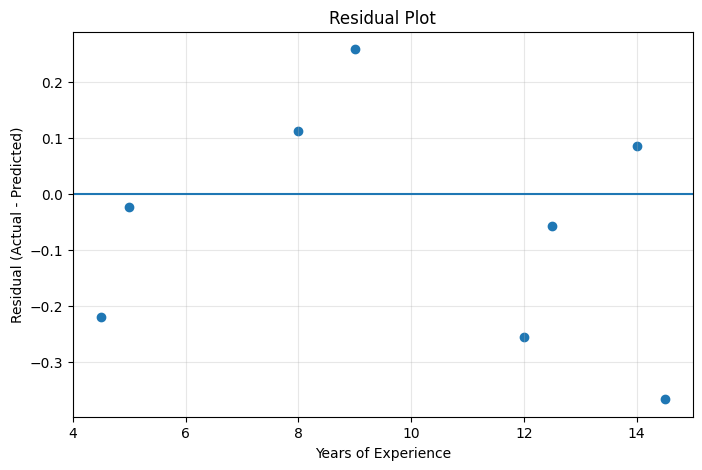

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(results["Experience"], results["Residual"])
plt.axhline(y=0)
plt.xlabel("Years of Experience")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(alpha=0.3)
plt.show()

# Discussion Question

### Question

If the scatter plot showed a **strong curve** instead of an approximately straight trend, would simple Linear Regression still be an appropriate first model?

### Discuss with your group

Consider:

1. What assumption does simple Linear Regression make about the relationship between X and y?
2. What might happen to the residuals when the true relationship is curved?
3. What other models or transformations could be considered?

### Your answer

Write 2–3 sentences below:

**Answer:**  
Linear relationship - If X increases y also increases. ___________________________________________________________________  
____________________________________________________________________  
____________________________________________________________________


# Optional Challenge — Compare 20% vs 25% Test Split

If time permits, train the same model twice:

- Model A → `test_size=0.20`
- Model B → `test_size=0.25`

Compare their:

- MAE
- RMSE
- R²

### Question

Did changing the test split change the evaluation metrics? Why might this happen?


In [ ]:
# OPTIONAL CHALLENGE

def evaluate_split(test_size):
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    temp_model = LinearRegression()
    temp_model.fit(X_train_temp, y_train_temp)

    temp_pred = temp_model.predict(X_test_temp)

    return {
        "Test Size": test_size,
        "MAE": mean_absolute_error(y_test_temp, temp_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_temp, temp_pred)),
        "R²": r2_score(y_test_temp, temp_pred)
    }

comparison = pd.DataFrame([
    evaluate_split(0.20),
    evaluate_split(0.25)
])

comparison

# Activity Completion Checklist

Before finishing, confirm that you have:

- [ ] Changed `test_size` from 0.20 to 0.25
- [ ] Retrained the Linear Regression model
- [ ] Recorded intercept and slope
- [ ] Calculated MAE, RMSE and R²
- [ ] Predicted salary for 4.5, 8 and 12 years
- [ ] Interpreted the slope
- [ ] Created the residual table
- [ ] Found the largest absolute residual
- [ ] Discussed whether Linear Regression is suitable for a curved relationship

**End of Faculty Hands-On Activity**
